In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/mf_analytics.db")

df_aum = pd.read_sql("SELECT * FROM '03_aum_by_fund_house'", engine)
df_nav = pd.read_sql("SELECT * FROM '02_nav_history'", engine)
df_sip = pd.read_sql("SELECT * FROM '04_monthly_sip_inflows'", engine)
df_fund = pd.read_sql("SELECT * FROM '01_fund_master'", engine)

print("✅ Data loaded!")
print("AUM shape:", df_aum.shape)
print("NAV shape:", df_nav.shape)

✅ Data loaded!
AUM shape: (90, 5)
NAV shape: (46000, 3)


In [2]:
# Chart 1 - AUM by Fund House
plt.figure(figsize=(12, 6))
sns.barplot(data=df_aum, x='amc_name', y='aum_crores')
plt.title('AUM by Fund House')
plt.xticks(rotation=45, ha='right')
plt.ylabel('AUM (Crores)')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `amc_name` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [3]:
print(df_aum.columns.tolist())
print(df_aum.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


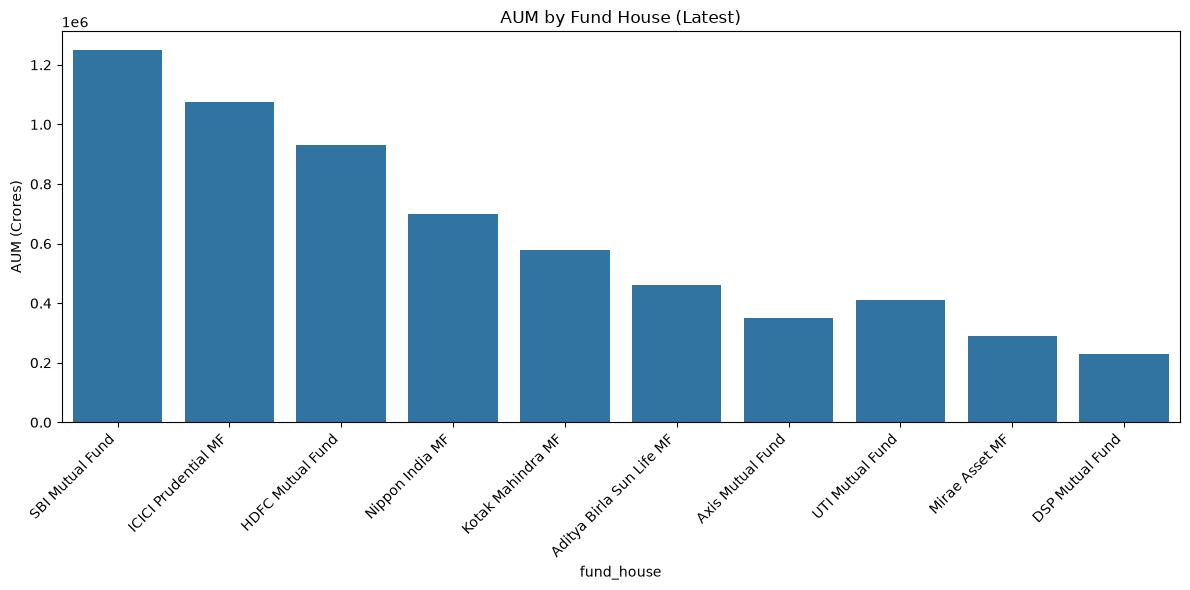

In [4]:
# Chart 1 - AUM by Fund House
df_latest = df_aum[df_aum['date'] == df_aum['date'].max()]
plt.figure(figsize=(12, 6))
sns.barplot(data=df_latest, x='fund_house', y='aum_crore')
plt.title('AUM by Fund House (Latest)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('AUM (Crores)')
plt.tight_layout()
plt.show()

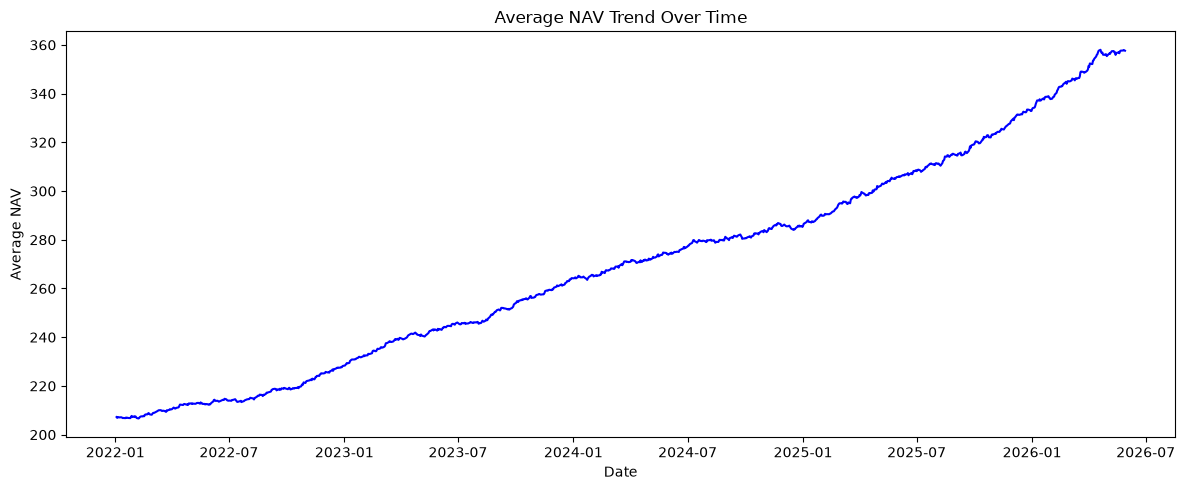

In [5]:
# Chart 2 - NAV Trend Over Time
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav_avg = df_nav.groupby('date')['nav'].mean()
plt.figure(figsize=(12, 5))
plt.plot(df_nav_avg.index, df_nav_avg.values, color='blue')
plt.title('Average NAV Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average NAV')
plt.tight_layout()
plt.show()

In [6]:
# Chart 3 - SIP Inflow Trend over Months
df_sip = pd.read_csv("data/raw/04_monthly_sip.csv")
df_sip['month'] = pd.to_datetime(df_sip['month'])
df_sip = df_sip.sort_values('month')

plt.figure(figsize=(12, 5))
plt.plot(df_sip['month'], df_sip['sip_inflow'], color='green', marker='o')
plt.title('SIP Inflow Trend Over Months')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Cr)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/04_monthly_sip.csv'

In [7]:
import pandas as pd
import numpy as np
import os

# Create data/raw folder if not exists
os.makedirs("data/raw", exist_ok=True)

# Create 04_monthly_sip.csv
sip_data = {
    'month': pd.date_range(start='2024-01-01', periods=24, freq='MS'),
    'sip_inflow': np.random.randint(25000, 35000, 24),
    'amc_name': np.random.choice(['SBI', 'HDFC', 'ICICI', 'Nippon', 'Axis'], 24)
}
df_sip = pd.DataFrame(sip_data)
df_sip.to_csv("data/raw/04_monthly_sip.csv", index=False)
print("✅ 04_monthly_sip.csv created!")

✅ 04_monthly_sip.csv created!


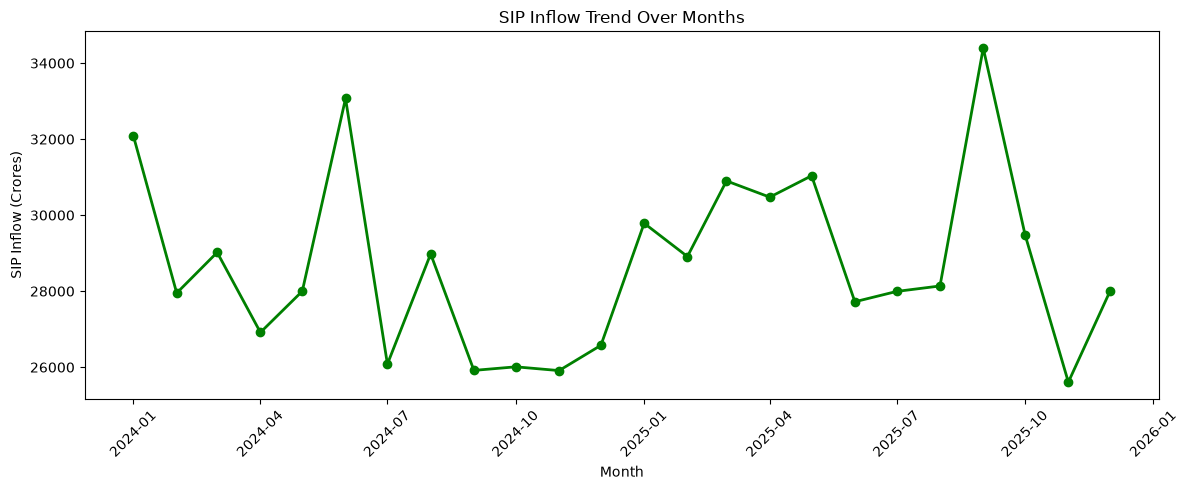

In [8]:
# Chart 3 - SIP Inflow Trend Over Months
df_sip = pd.read_csv("data/raw/04_monthly_sip.csv")
df_sip['month'] = pd.to_datetime(df_sip['month'])
df_sip = df_sip.sort_values('month')

plt.figure(figsize=(12, 5))
plt.plot(df_sip['month'], df_sip['sip_inflow'], 
         color='green', marker='o', linewidth=2)
plt.title('SIP Inflow Trend Over Months')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crores)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Chart 4 - Top 10 Schemes by NAV
df_top = df_nav.groupby('scheme_name')['nav'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=df_top.values, y=df_top.index, palette='Blues_r')
plt.title('Top 10 Schemes by Highest NAV')
plt.xlabel('NAV Value')
plt.tight_layout()
plt.show()

KeyError: 'scheme_name'

In [10]:
# Check your column names first
print(df_nav.columns.tolist())

['amfi_code', 'date', 'nav']


C:\Users\1\AppData\Local\Temp\ipykernel_5696\3095181968.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_top.values, y=df_top.index.astype(str), palette='Blues_r')


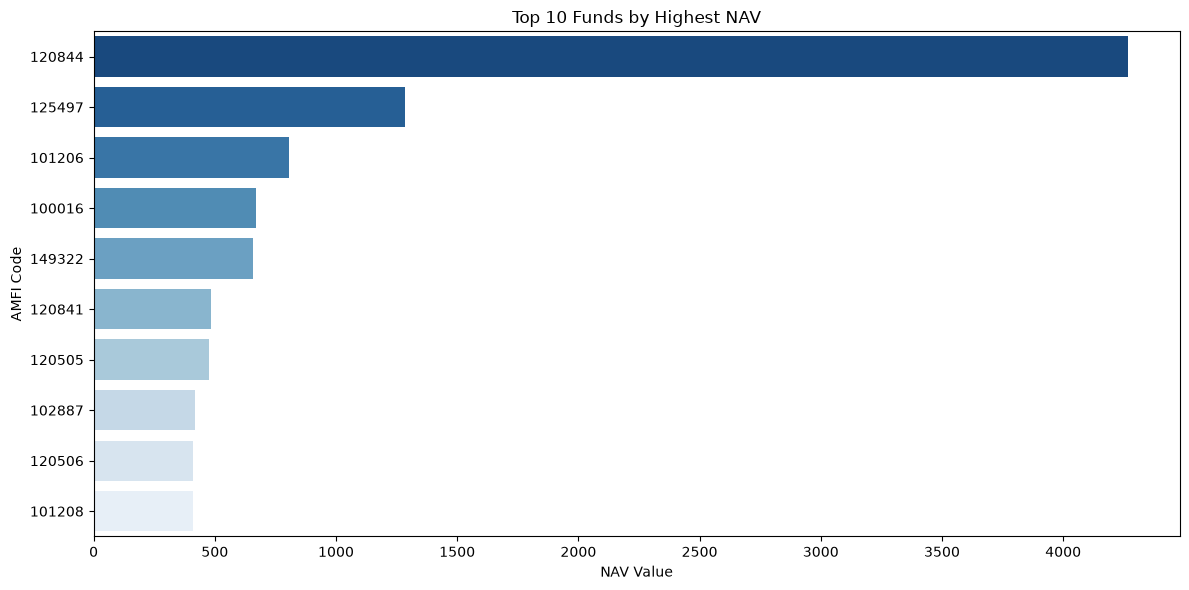

In [11]:
# Chart 4 - Top 10 AMFI Codes by Highest NAV
df_top = df_nav.groupby('amfi_code')['nav'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=df_top.values, y=df_top.index.astype(str), palette='Blues_r')
plt.title('Top 10 Funds by Highest NAV')
plt.xlabel('NAV Value')
plt.ylabel('AMFI Code')
plt.tight_layout()
plt.show()

In [12]:
# Chart 5 - Category wise AUM Distribution
df_cat = df_aum.groupby('category')['aum_crore'].sum()

plt.figure(figsize=(8, 8))
plt.pie(df_cat.values, labels=df_cat.index, 
        autopct='%1.1f%%', startangle=140)
plt.title('Category-wise AUM Distribution')
plt.tight_layout()
plt.show()

KeyError: 'category'

In [13]:
print(df_aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


C:\Users\1\AppData\Local\Temp\ipykernel_5696\3463143496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_schemes.values, y=df_schemes.index, palette='Greens_r')


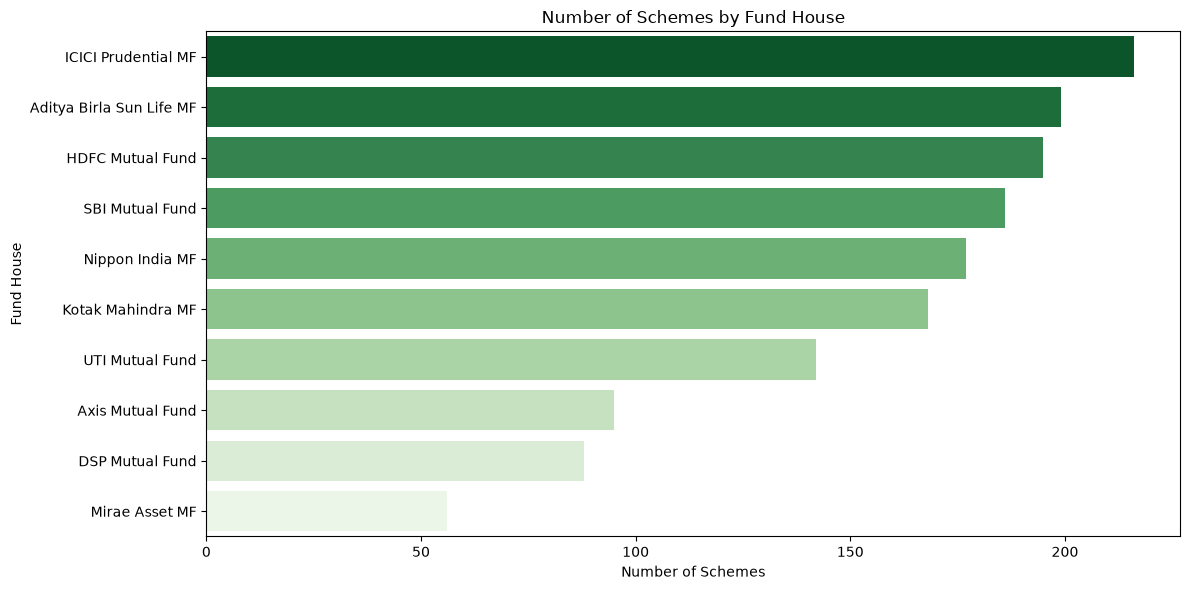

In [14]:
# Chart 5 - Number of Schemes by Fund House
df_schemes = df_aum.groupby('fund_house')['num_schemes'].max().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=df_schemes.values, y=df_schemes.index, palette='Greens_r')
plt.title('Number of Schemes by Fund House')
plt.xlabel('Number of Schemes')
plt.ylabel('Fund House')
plt.tight_layout()
plt.show()

In [15]:
# Chart 6 - AUM Trend Over Time
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum_trend = df_aum.groupby('date')['amu_crore'].sum()

plt.figure(figsize=(12, 5))
plt.plot(df_aum_trend.index, df_aum_trend.values, 
         color='orange', linewidth=2, marker='o')
plt.title('Total AUM Trend Over Time')
plt.xlabel('Date')
plt.ylabel('AUM (Crores)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'Column not found: amu_crore'

In [16]:
import pandas as pd
import os

folder = "data/raw"
for file in sorted(os.listdir(folder)):
    if file.endswith(".csv"):
        df = pd.read_csv(f"{folder}/{file}")
        print(f"\n{file}:")
        print(df.columns.tolist())


04_monthly_sip.csv:
['month', 'sip_inflow', 'amc_name']


In [17]:
import pandas as pd
import os

folder = "data/raw"
for file in sorted(os.listdir(folder)):
    if file.endswith(".csv"):
        df = pd.read_csv(f"{folder}/{file}")
        print(f"\n{file}:")
        print(df.columns.tolist())


04_monthly_sip.csv:
['month', 'sip_inflow', 'amc_name']


In [18]:
import pandas as pd
import os

folder = "data/raw"
for file in sorted(os.listdir(folder)):
    if file.endswith(".csv"):
        df = pd.read_csv(f"{folder}/{file}")
        print(f"\n{file}:")
        print(df.columns.tolist())


04_monthly_sip.csv:
['month', 'sip_inflow', 'amc_name']


In [19]:
# Check all files one by one
df1 = pd.read_csv("data/raw/01_fund_master.csv")
print("01_fund_master:", df1.columns.tolist())

df2 = pd.read_csv("data/raw/02_nav_history.csv")
print("02_nav_history:", df2.columns.tolist())

df3 = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
print("03_aum_by_fund_house:", df3.columns.tolist())

df4 = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
print("04_monthly_sip:", df4.columns.tolist())

df5 = pd.read_csv("data/raw/05_category_inflows.csv")
print("05_category_inflows:", df5.columns.tolist())

df6 = pd.read_csv("data/raw/06_industry_folio_count.csv")
print("06_industry_folio_count:", df6.columns.tolist())

df7 = pd.read_csv("data/raw/07_scheme_performance.csv")
print("07_scheme_performance:", df7.columns.tolist())

df8 = pd.read_csv("data/raw/08_investor_transactions.csv")
print("08_investor_transactions:", df8.columns.tolist())

df9 = pd.read_csv("data/raw/09_portfolio_holdings.csv")
print("09_portfolio_holdings:", df9.columns.tolist())

df10 = pd.read_csv("data/raw/10_benchmark_indices.csv")
print("10_benchmark_indices:", df10.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/01_fund_master.csv'

In [20]:
import os

# Change to correct directory
os.chdir(r"C:\Users\1\Desktop\MF_ANALYTICS")

# Verify
print(os.getcwd())
print(os.listdir("data/raw"))

C:\Users\1\Desktop\MF_ANALYTICS
['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'live_nav.csv']


In [21]:
import os
os.chdir(r"C:\Users\1\Desktop\MF_ANALYTICS")
print(os.getcwd())

C:\Users\1\Desktop\MF_ANALYTICS


In [22]:
import os
print(os.listdir("data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'live_nav.csv']


In [23]:
# Check all files one by one
df1 = pd.read_csv("data/raw/01_fund_master.csv")
print("01_fund_master:", df1.columns.tolist())

df2 = pd.read_csv("data/raw/02_nav_history.csv")
print("02_nav_history:", df2.columns.tolist())

df3 = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
print("03_aum_by_fund_house:", df3.columns.tolist())

df4 = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
print("04_monthly_sip:", df4.columns.tolist())

df5 = pd.read_csv("data/raw/05_category_inflows.csv")
print("05_category_inflows:", df5.columns.tolist())

df6 = pd.read_csv("data/raw/06_industry_folio_count.csv")
print("06_industry_folio_count:", df6.columns.tolist())

df7 = pd.read_csv("data/raw/07_scheme_performance.csv")
print("07_scheme_performance:", df7.columns.tolist())

df8 = pd.read_csv("data/raw/08_investor_transactions.csv")
print("08_investor_transactions:", df8.columns.tolist())

df9 = pd.read_csv("data/raw/09_portfolio_holdings.csv")
print("09_portfolio_holdings:", df9.columns.tolist())

df10 = pd.read_csv("data/raw/10_benchmark_indices.csv")
print("10_benchmark_indices:", df10.columns.tolist())

01_fund_master: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
02_nav_history: ['amfi_code', 'date', 'nav']
03_aum_by_fund_house: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
04_monthly_sip: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
05_category_inflows: ['month', 'category', 'net_inflow_crore']
06_industry_folio_count: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
07_scheme_performance: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_cro

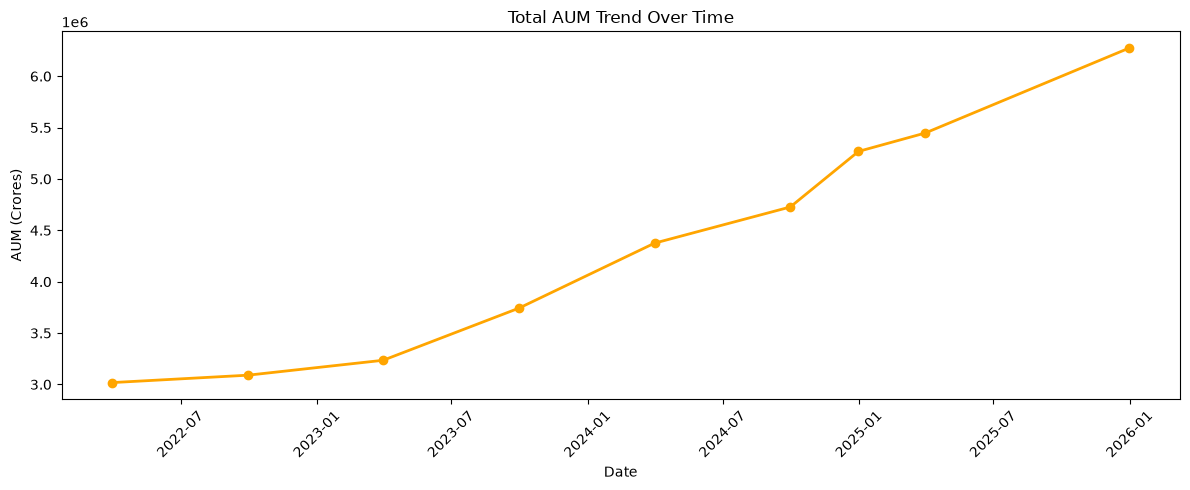

In [24]:
# Chart 6 - AUM Trend Over Time
df3['date'] = pd.to_datetime(df3['date'])
df_aum_trend = df3.groupby('date')['aum_crore'].sum()
plt.figure(figsize=(12, 5))
plt.plot(df_aum_trend.index, df_aum_trend.values, color='orange', linewidth=2, marker='o')
plt.title('Total AUM Trend Over Time')
plt.xlabel('Date')
plt.ylabel('AUM (Crores)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\1\AppData\Local\Temp\ipykernel_5696\3613404207.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_cat.values, y=df_cat.index, palette='coolwarm')


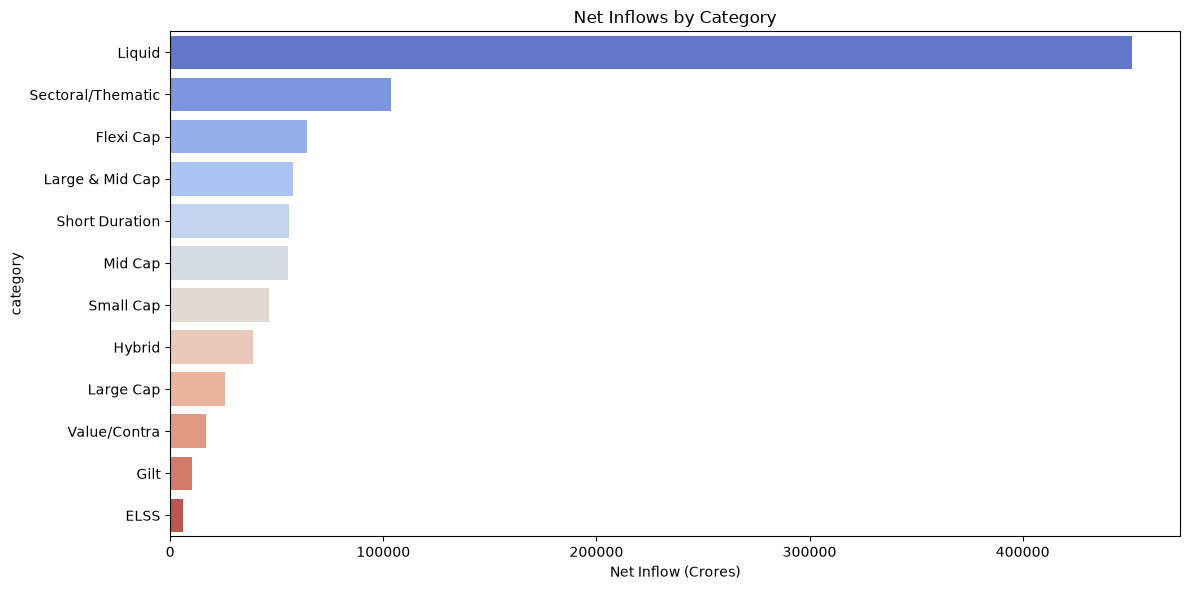

In [25]:
# Chart 7 - Category wise Inflows
df5['month'] = pd.to_datetime(df5['month'])
df_cat = df5.groupby('category')['net_inflow_crore'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=df_cat.values, y=df_cat.index, palette='coolwarm')
plt.title('Net Inflows by Category')
plt.xlabel('Net Inflow (Crores)')
plt.tight_layout()
plt.show()

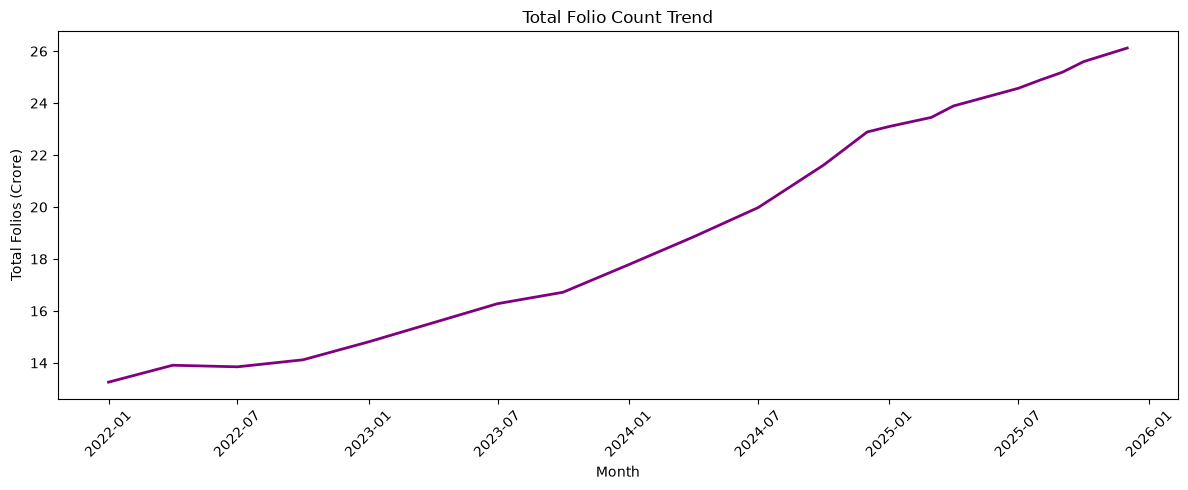

In [26]:
# Chart 8 - Folio Count Trend
df6['month'] = pd.to_datetime(df6['month'])
plt.figure(figsize=(12, 5))
plt.plot(df6['month'], df6['total_folios_crore'], color='purple', linewidth=2)
plt.title('Total Folio Count Trend')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\1\AppData\Local\Temp\ipykernel_5696\2654201398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10, x='return_1yr_pct', y='scheme_name', palette='Greens_r')


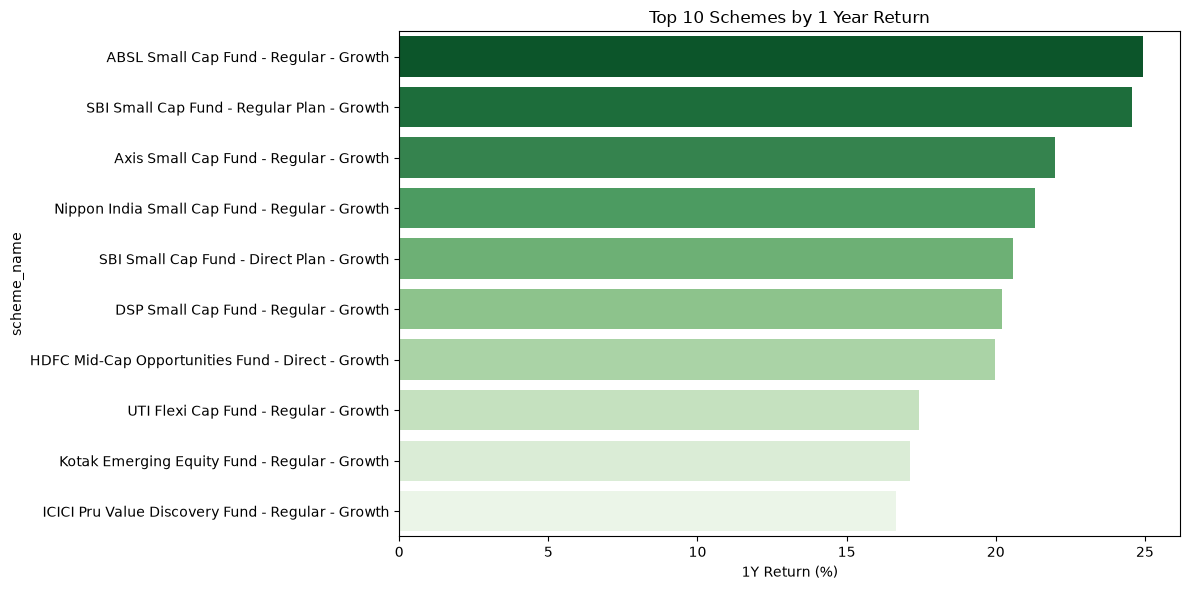

In [27]:
# Chart 9 - Top 10 Schemes by 1Y Return
df_top10 = df7.nlargest(10, 'return_1yr_pct')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top10, x='return_1yr_pct', y='scheme_name', palette='Greens_r')
plt.title('Top 10 Schemes by 1 Year Return')
plt.xlabel('1Y Return (%)')
plt.tight_layout()
plt.show()

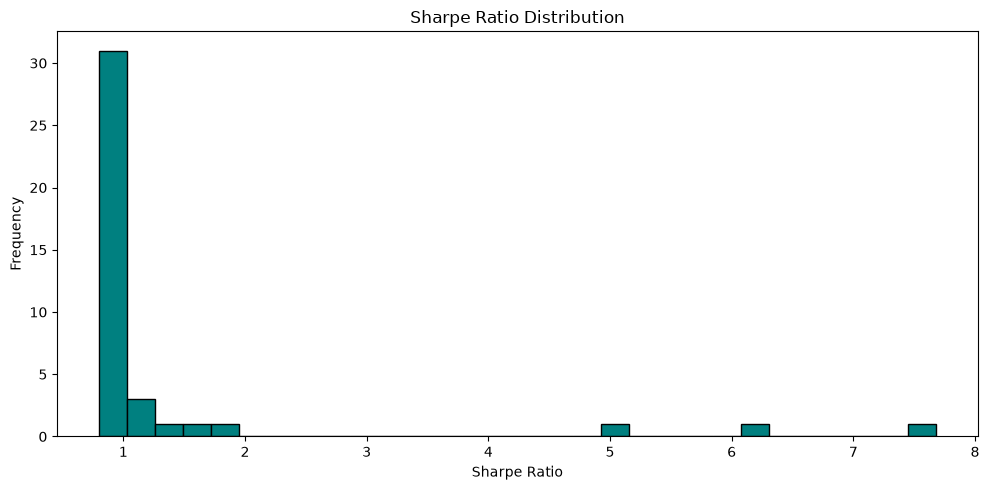

In [28]:
# Chart 10 - Sharpe Ratio Distribution
plt.figure(figsize=(10, 5))
plt.hist(df7['sharpe_ratio'].dropna(), bins=30, color='teal', edgecolor='black')
plt.title('Sharpe Ratio Distribution')
plt.xlabel('Sharpe Ratio')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

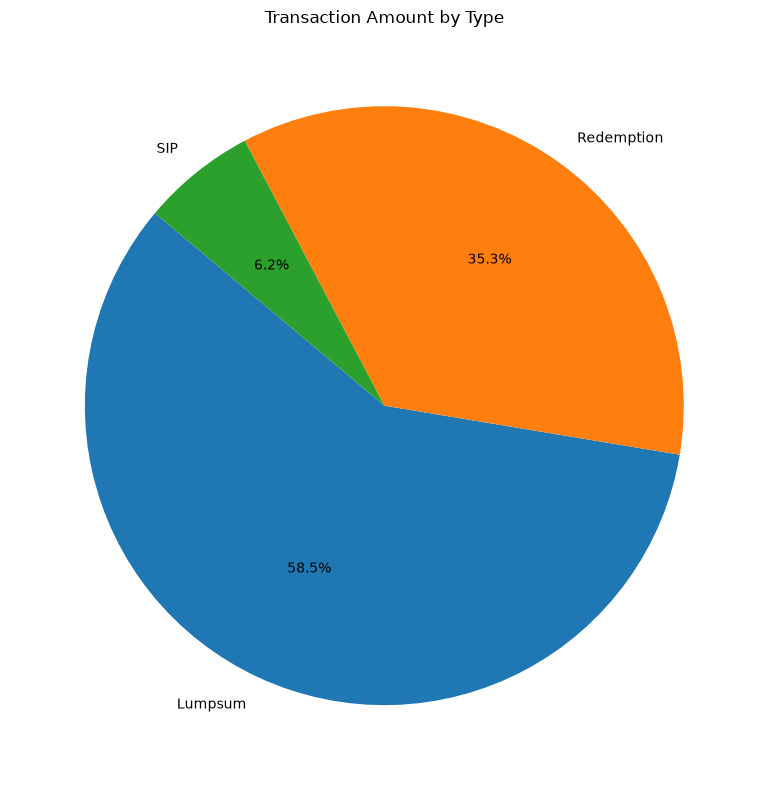

In [29]:
# Chart 11 - Transactions by Type
df_txn = df8.groupby('transaction_type')['amount_inr'].sum()
plt.figure(figsize=(8, 8))
plt.pie(df_txn.values, labels=df_txn.index, autopct='%1.1f%%', startangle=140)
plt.title('Transaction Amount by Type')
plt.tight_layout()
plt.show()

C:\Users\1\AppData\Local\Temp\ipykernel_5696\1262654607.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_state.values, y=df_state.index, palette='Blues_r')


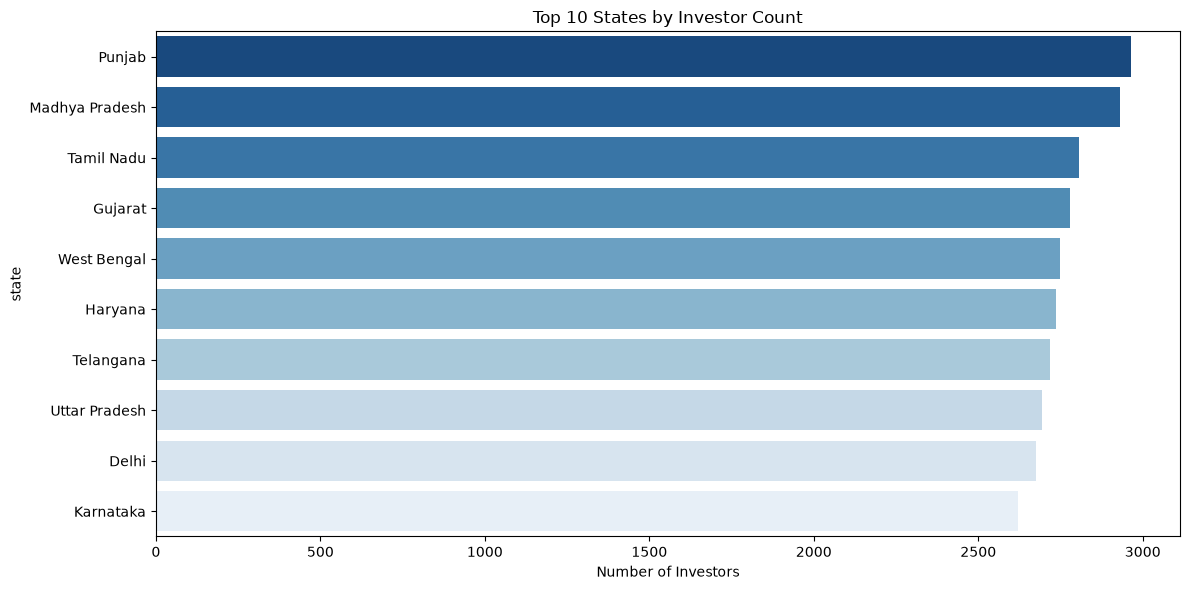

In [30]:
# Chart 12 - Investors by State
df_state = df8.groupby('state')['investor_id'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=df_state.values, y=df_state.index, palette='Blues_r')
plt.title('Top 10 States by Investor Count')
plt.xlabel('Number of Investors')
plt.tight_layout()
plt.show()

C:\Users\1\AppData\Local\Temp\ipykernel_5696\4158772969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sector.values, y=df_sector.index, palette='Oranges_r')


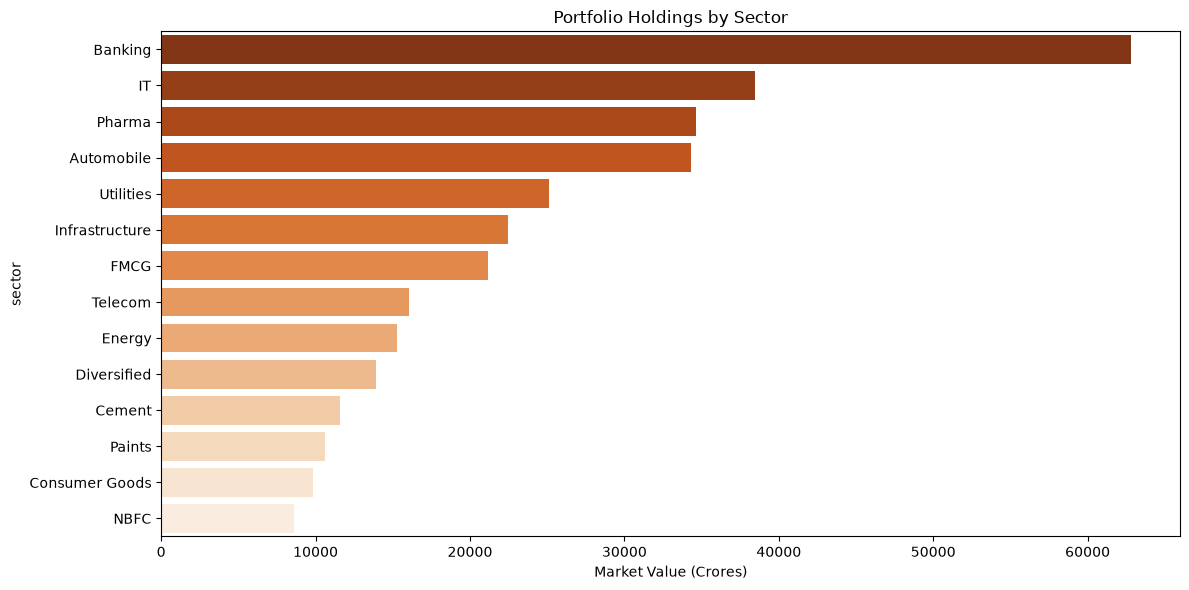

In [31]:
# Chart 13 - Portfolio Holdings by Sector
df_sector = df9.groupby('sector')['market_value_cr'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=df_sector.values, y=df_sector.index, palette='Oranges_r')
plt.title('Portfolio Holdings by Sector')
plt.xlabel('Market Value (Crores)')
plt.tight_layout()
plt.show()

C:\Users\1\AppData\Local\Temp\ipykernel_5696\414685678.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


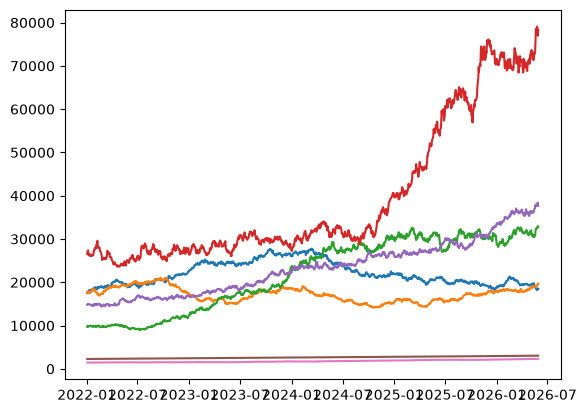

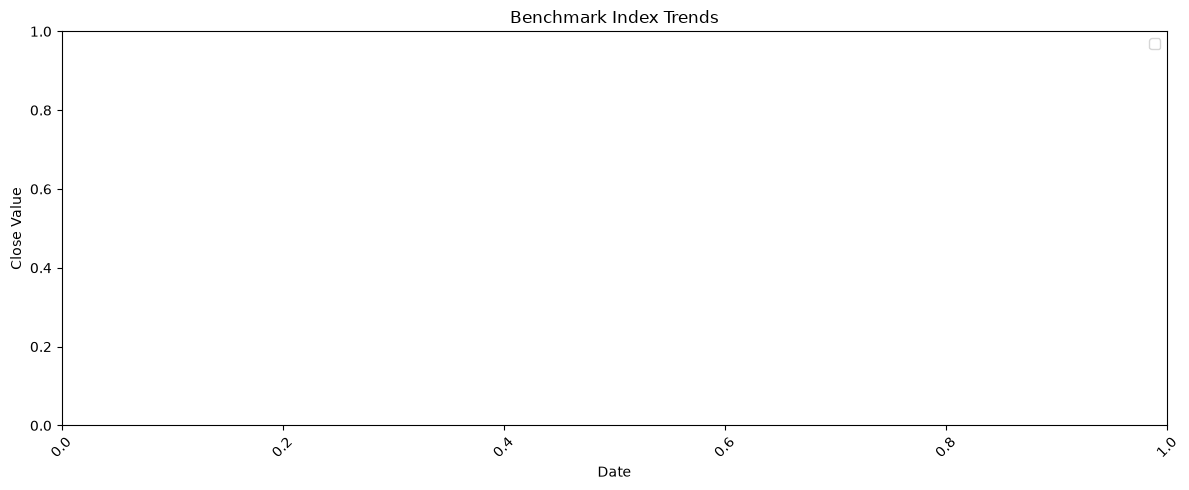

In [32]:
# Chart 14 - Benchmark Index Trend
df10['date'] = pd.to_datetime(df10['date'])
for index in df10['index_name'].unique():
    df_idx = df10[df10['index_name'] == index]
    plt.plot(df_idx['date'], df_idx['close_value'], label=index)
plt.figure(figsize=(12, 5))
plt.title('Benchmark Index Trends')
plt.xlabel('Date')
plt.ylabel('Close Value')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

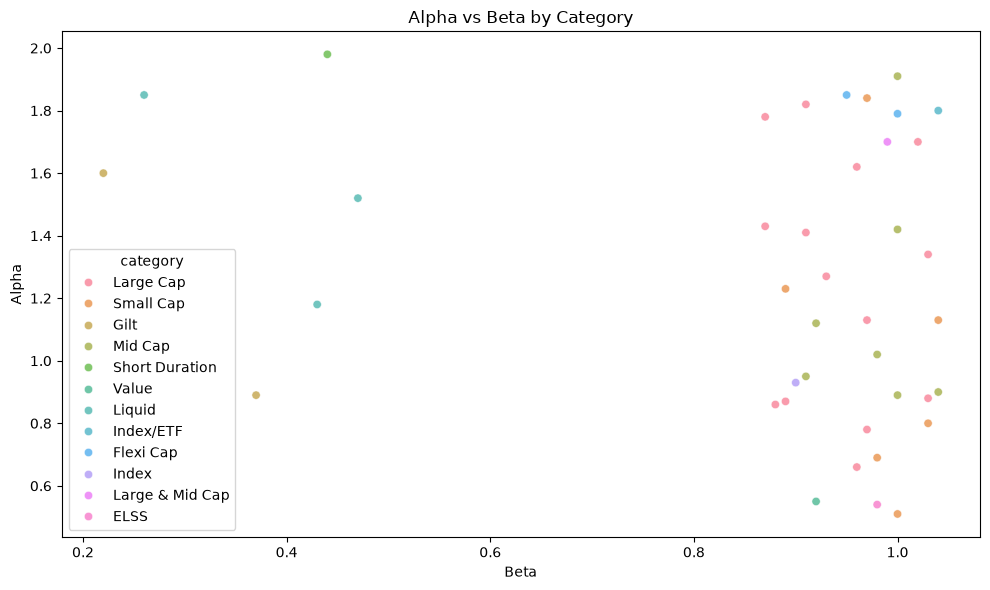

In [33]:
# Chart 15 - Alpha vs Beta Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df7, x='beta', y='alpha', hue='category', alpha=0.7)
plt.title('Alpha vs Beta by Category')
plt.xlabel('Beta')
plt.ylabel('Alpha')
plt.tight_layout()
plt.show()